In [1]:
%matplotlib inline

import os
import sys
import copy

import torch
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append('../../../')

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.yolov11_pose.nn.tasks import PoseModel
from computer_vision.yolov11_pose.utils.metrics import DetMetrics, PoseMetrics, box_iou
from computer_vision.yolov11_pose.engine.validator import DectectionValidator
from computer_vision.yolov11_pose.model.validator import PoseValidator
from computer_vision.yolov11_pose.utils.checks import check_imgsz
from computer_vision.yolov11_pose.data.utils import check_det_dataset
from computer_vision.yolov11_pose.data.build import build_yolo_dataset, build_dataloader
from computer_vision.yolov11_pose.cfg import get_cfg
from computer_vision.yolov11_pose.utils.torch_utils import unwrap_model
from computer_vision.yolov11_pose.utils.nms import non_max_suppression # for post processing
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy, xyxy2xywh

In [8]:
main_dirpath='D:/results/yolov11_pose'
checkpoint_dirpath=os.path.join(main_dirpath, 'predict')
args=parser.parse_args(f' --data ../coco-pose.yaml --visualize'.split())


task='pose'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco-pose/images/val2017'
    data_config='../coco-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/val2017'
    data_config='../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg/images/val'
    data_config='../coco8-seg.yaml'



hyp=get_cfg()
dataset=build_yolo_dataset(args=args, cfg=hyp, task=task, img_path=data_dirpath, batch=args.batch_size or hyp.batch, 
                   data=data_config,  mode='val', rect=False, stride=32, channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)
dataloader=build_dataloader(dataset, batch=hyp.batch, workers=1, shuffle=True, drop_last=True, pin_memory=True)


In data.build.build_yolo_dataset batch 16
In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco-pose\labels\val2017.cache
Scanning D:\data\ultralytics\coco-pose\labels\val2017.cache... 2346 images, 2654 backgrounds, 0 corrupts
In data.dataset.YOLODataset.__init__ augment False rect False
(1, 1)
(0, 1)
(0, 1)
(0, 1)
In data.build.build_dataloader batch 16


In [3]:
cfg='../yolo11-pose.yaml'
model=PoseModel(cfg=cfg,nc=1,verbose=True)
model.fuse(); # we need to call `fuse` so we can successfully load pretrained weight
checkpoint_file=os.path.join(checkpoint_dirpath, 'yolo11n_torch.pt')
assert os.path.isfile(checkpoint_file), f'{checkpoint_file} does not exist'
checkpoint=torch.load(checkpoint_file, weights_only=False)
try:
    model.load_state_dict(checkpoint['model'])
except RuntimeError as err:
    state_dict=copy.deepcopy(model.state_dict())
    for name, params in checkpoint['model'].items():
        name=name[len('model.'):] # each parameter name is model.model.xxx so we need to remove 1 model.
        
        if name not in state_dict or params.shape!=state_dict[name].shape:
            print(name, name in state_dict, (params.shape,state_dict[name].shape) if name in state_dict else None)
        else: state_dict[name]=params
    model.load_state_dict(state_dict)

In nn.tasks.PoseModel.__init__ type(cfg) <class 'str'>, cfg ../yolo11-pose.yaml
In nn.tasks.parse_model d {'nc': 1, 'kpt_shape': [17, 3], 'scales': {'n': [0.5, 0.25, 1024], 's': [0.5, 0.5, 1024], 'm': [0.5, 1.0, 512], 'l': [1.0, 1.0, 512], 'x': [1.0, 1.5, 512]}, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 2, 'C3k2', [256, False, 0.25]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 2, 'C3k2', [512, False, 0.25]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 2, 'C3k2', [1024, True]], [-1, 1, 'SPPF', [1024, 5]], [-1, 2, 'C2PSA', [1024]]], 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 2, 'C3k2', [256, False]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 13], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 2, 

0,1,

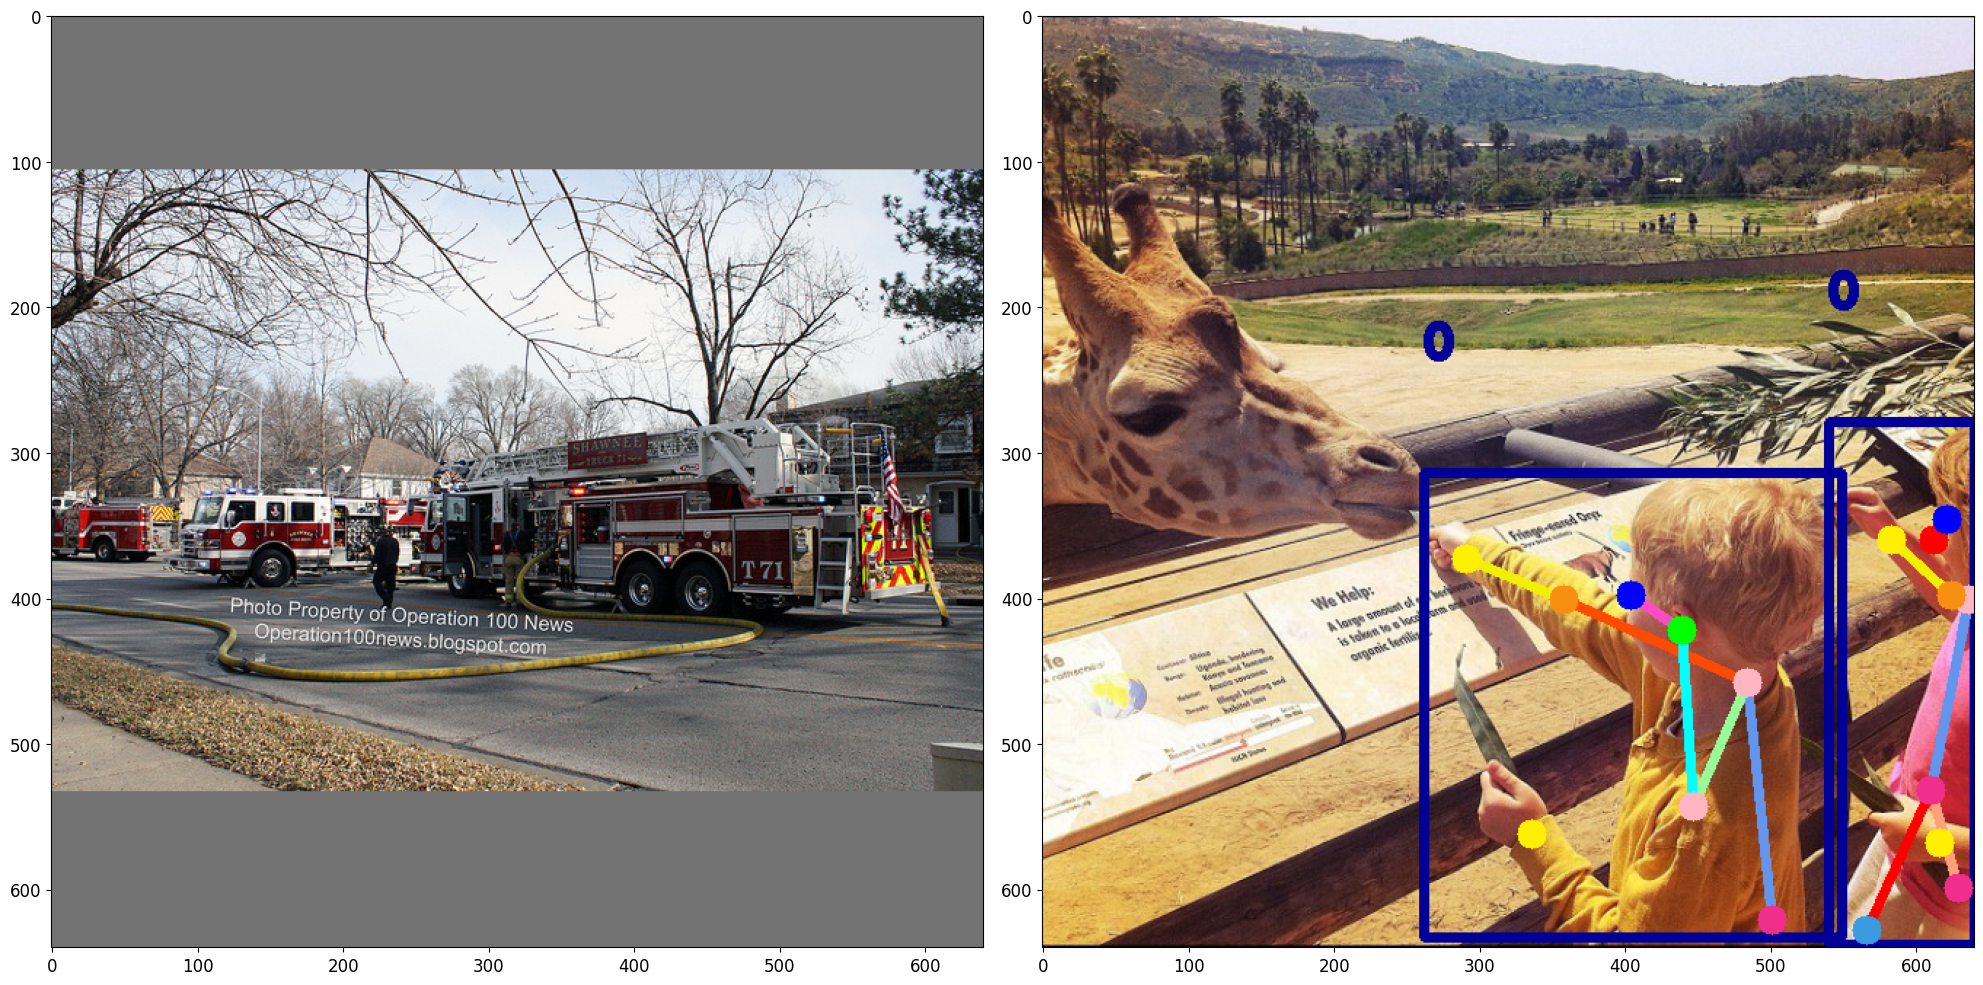

In [9]:
from computer_vision.misc import alpha_bending, instance2mask

from matplotlib import patches
import matplotlib.pyplot as plt
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

n_data=2
ncols=2
nrows=int(np.ceil(n_data/ncols))

_, ax=plt.subplots(nrows,ncols,figsize=(20,20))
for idx, item in enumerate(dataloader):
    if idx==n_data: break
    print(idx, end=',')
    batch_idx=item['batch_idx']
    flag=batch_idx==idx

    classes=item['cls'][flag].flatten() # (N,1) to (N,)
    classes=[f'{int(c)}' for c in classes]
    img=item['img'][idx] # (C,H,W)
    height, width=img.shape[-2:]
    if isinstance(img, torch.Tensor):
        img=img.permute(1,2,0).contiguous().numpy() # HxWxC
        img=img[...,::-1] # RGB to BGR

    bboxes=item['bboxes'][flag].clone()
    bboxes=xywh2xyxy(bboxes)
    # denormalize bboxes
    bboxes[...,[0,2]]*=width
    bboxes[...,[1,3]]*=height
    bboxes=bboxes.numpy()
    
    keypoints=item['keypoints'][flag].clone() if 'keypoints' in item else None # NxMx3
    if keypoints is not None: # denormalized
        keypoints[...,0]*=width
        keypoints[...,1]*=height
        keypoints=keypoints.numpy()
    if keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[idx].imshow(img[...,::-1])
    else: ax[idx].imshow(img[...,::-1])
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[idx].add_patch(rect)
            ax[idx].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()


In [12]:
batch=copy.deepcopy(item)
# preprocess batch
batch['img']=batch['img'].float()/255

In [29]:
y=[]
x=batch['img'].clone()
for i, (n, m) in enumerate(model.model.named_children()):
    print(n, '-'*50)
    if m.f!=-1: # if not from previous layer
        x=y[m.f] if isinstance(m.f, int) else [x if j==-1 else y[j] for j in m.f] # from eariler layers
    print('m.f ', m.f, ' x ', x.shape if isinstance(x, torch.Tensor) else [v.shape for v in x], end=',')
    x=m(x)
    txt=f'{[v.shape for v in x[0]]} and {x[1].shape}' if isinstance(x, tuple) else f'{x.shape if isinstance(x, torch.Tensor) else [v.shape for v in x]}'
    print(' out x ', txt, ' m.i ', m.i, ' m.i in save ', m.i in model.save)
    y.append(x if m.i in model.save else None)


0 --------------------------------------------------
m.f  -1  x  torch.Size([16, 3, 640, 640]), out x  torch.Size([16, 16, 320, 320])  m.i  0  m.i in save  False
1 --------------------------------------------------
m.f  -1  x  torch.Size([16, 16, 320, 320]), out x  torch.Size([16, 32, 160, 160])  m.i  1  m.i in save  False
2 --------------------------------------------------
m.f  -1  x  torch.Size([16, 32, 160, 160]), out x  torch.Size([16, 64, 160, 160])  m.i  2  m.i in save  False
3 --------------------------------------------------
m.f  -1  x  torch.Size([16, 64, 160, 160]), out x  torch.Size([16, 64, 80, 80])  m.i  3  m.i in save  False
4 --------------------------------------------------
m.f  -1  x  torch.Size([16, 64, 80, 80]), out x  torch.Size([16, 128, 80, 80])  m.i  4  m.i in save  True
5 --------------------------------------------------
m.f  -1  x  torch.Size([16, 128, 80, 80]), out x  torch.Size([16, 128, 40, 40])  m.i  5  m.i in save  False
6 -----------------------------

In [38]:
m.xyxy

False

In [33]:
m.cv2

ModuleList(
  (0): Sequential(
    (0): Conv(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (1): Sequential(
    (0): Conv(
      (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (2): Sequential(
    (0): Conv(
      (conv): Conv2d(256, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (

In [34]:
m.cv3

ModuleList(
  (0): Sequential(
    (0): Sequential(
      (0): DWConv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
    (1): Sequential(
      (0): DWConv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
    (2): Conv2d(64, 1, kernel_size=(1, 1), stride=(1, 1))
  )
  (1): Sequential(
    (0): Sequential(
      (0): DWConv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
        (act):

In [35]:
m.cv4

ModuleList(
  (0): Sequential(
    (0): Conv(
      (conv): Conv2d(64, 51, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(51, 51, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): Conv2d(51, 51, kernel_size=(1, 1), stride=(1, 1))
  )
  (1): Sequential(
    (0): Conv(
      (conv): Conv2d(128, 51, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(51, 51, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): Conv2d(51, 51, kernel_size=(1, 1), stride=(1, 1))
  )
  (2): Sequential(
    (0): Conv(
      (conv): Conv2d(256, 51, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(51, 51, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (